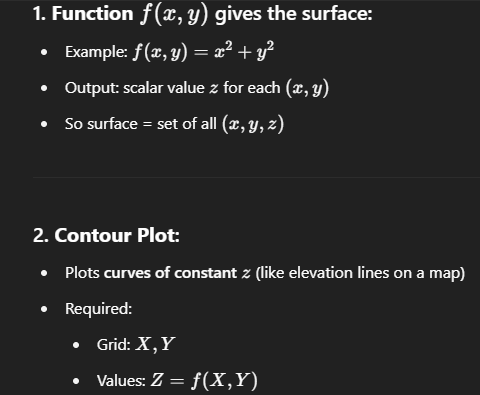
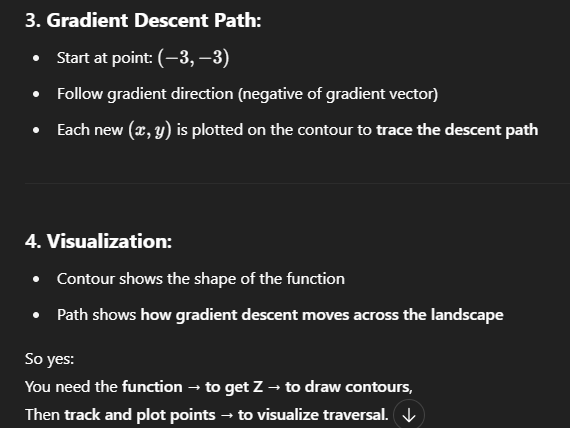

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.float_format = '${:,.2f}'.format

# Function and gradient
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

In [2]:
# Grid for contour
X, Y = np.meshgrid(np.linspace(-3.5, 3.5, 100), np.linspace(-3.5, 3.5, 100))
Z = f(X, Y)
# Z is used to plot the contour using different values of X, Y which is just 2d representation of [X, Y, Z]

In [3]:
Z.shape

(100, 100)

In [4]:
grad_f(-3, -3)

array([-6, -6])

In [5]:
grad_f(3, 3)

array([6, 6])

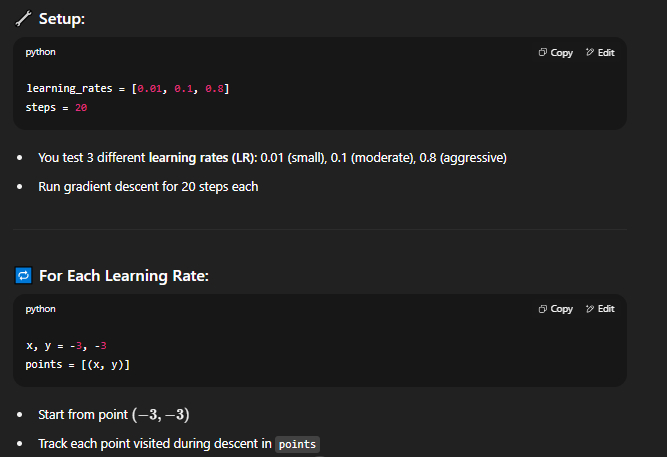


[(-3, -3), (-2.94, -2.94), (-2.88, -2.88), (-2.82, -2.82), (-2.77, -2.77), (-2.71, -2.71), (-2.66, -2.66), (-2.6, -2.6), (-2.55, -2.55), (-2.5, -2.5), (-2.45, -2.45), (-2.4, -2.4), (-2.35, -2.35), (-2.31, -2.31), (-2.26, -2.26), (-2.22, -2.22), (-2.17, -2.17), (-2.13, -2.13), (-2.09, -2.09), (-2.04, -2.04), (-2.0, -2.0)]


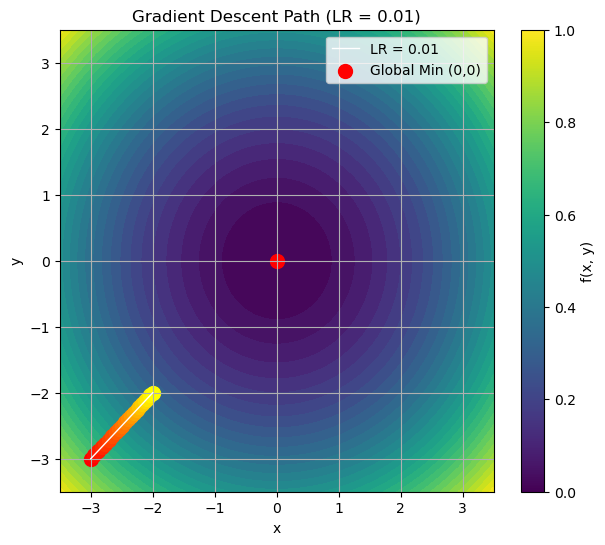

[(-3, -3), (-2.4, -2.4), (-1.92, -1.92), (-1.54, -1.54), (-1.23, -1.23), (-0.98, -0.98), (-0.79, -0.79), (-0.63, -0.63), (-0.5, -0.5), (-0.4, -0.4), (-0.32, -0.32), (-0.26, -0.26), (-0.21, -0.21), (-0.16, -0.16), (-0.13, -0.13), (-0.11, -0.11), (-0.08, -0.08), (-0.07, -0.07), (-0.05, -0.05), (-0.04, -0.04), (-0.03, -0.03)]


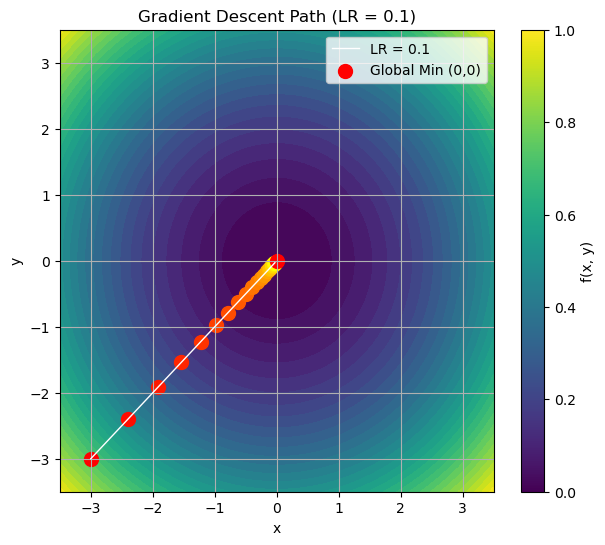

[(-3, -3), (1.8, 1.8), (-1.08, -1.08), (0.65, 0.65), (-0.39, -0.39), (0.23, 0.23), (-0.14, -0.14), (0.08, 0.08), (-0.05, -0.05), (0.03, 0.03), (-0.02, -0.02), (0.01, 0.01), (-0.01, -0.01), (0.0, 0.0), (-0.0, -0.0), (0.0, 0.0), (-0.0, -0.0), (0.0, 0.0), (-0.0, -0.0), (0.0, 0.0), (-0.0, -0.0)]


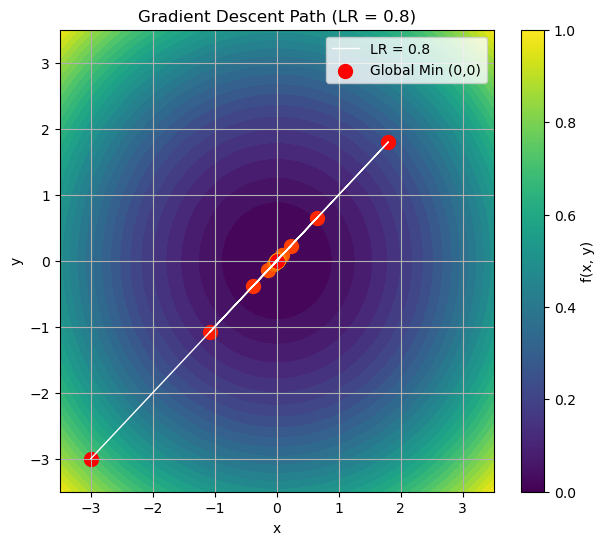

[(-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3), (3, 3), (-3, -3)]


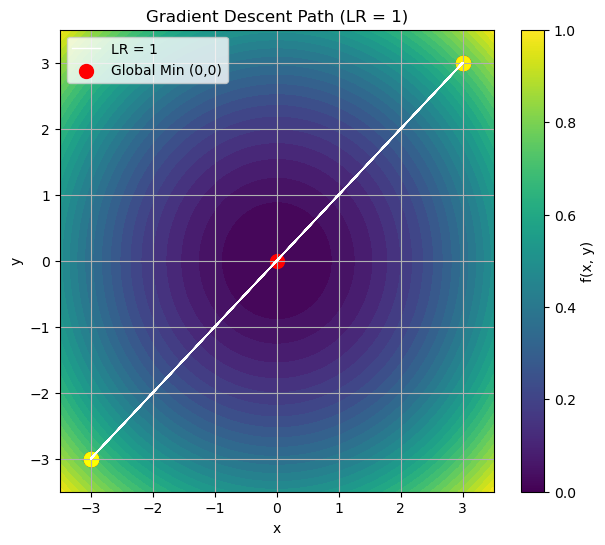

In [7]:
learning_rates = [0.01, 0.1, 0.8, 1]
steps = 20

for lr in learning_rates:
    x, y = -3, -3  # Reset for each run
    points = [(x, y)]

    for _ in range(steps):
        grad = grad_f(x, y)    # gradient vector  x(-3) -> -3 - 0.01*-6 -> -2.94
        x -= lr * grad[0]
        y -= lr * grad[1]
        points.append((np.round(x, 2), np.round(y, 2))) #remove round for more accuracy

    # Extract for plotting
    xs, ys = zip(*points)

    print(points)
    # Plot
    plt.figure(figsize=(7, 6))
    plt.contourf(X, Y, Z, levels=30, cmap='viridis')
    plt.plot(xs, ys, color='white', linewidth=1, label=f'LR = {lr}')

    # Gradient dot color fade: from light yellow to dark orange
    for i in range(len(xs)):
        plt.scatter(xs[i], ys[i], color=plt.cm.autumn(i / steps), s=100)

    plt.scatter(0, 0, color='red', s=100, label='Global Min (0,0)')
    plt.title(f'Gradient Descent Path (LR = {lr})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.colorbar(label='f(x, y)')
    plt.show()